## Georg Seismic Experiment

Explore seismic signals at Bonn

## Imports

In [2]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np
import obspy as obs
import pandas as pd

from obspy.signal import PPSD

from andbro__read_sds import __read_sds
from andbro__trim_stream import __trim_stream

## Configurations

In [11]:
config = {}

config['workdir'] = "/home/andbro/"
# config['workdir'] = "/import/"

config['path_to_inv'] = config['workdir']+"kilauea-data/GEORG/stationxml/"

config['path_to_data'] = config['workdir']+"kilauea-data/GEORG/data/"

config['path_to_figs'] = config['workdir']+"kilauea-data/GEORG/figs/"

# config['tbeg'] = obs.UTCDateTime("2024-12-17 02:00")
# config['tend'] = obs.UTCDateTime("2024-12-17 04:00")

# config['tbeg'] = obs.UTCDateTime("2024-12-17 05:00")
# config['tend'] = obs.UTCDateTime("2024-12-17 06:00")

# Kuril Islands
config['tbeg'] = obs.UTCDateTime("2024-12-27 12:47:00")
config['tend'] = obs.UTCDateTime("2024-12-27 14:47:00")

# South Sandwich Islands
# config['tbeg'] = obs.UTCDateTime("2025-01-01 13:48:00")
# config['tend'] = obs.UTCDateTime("2025-01-01 15:48:00")

# Small Event
# config['tbeg'] = obs.UTCDateTime("2024-12-21 13:20:00")
# config['tend'] = obs.UTCDateTime("2024-12-21 13:30:00")

# Calibration
# config['tbeg'] = obs.UTCDateTime("2024-12-19 13:08:00")
# config['tend'] = obs.UTCDateTime("2024-12-19 13:14:00")


### Load Data

### Load Seismometer Data

In [12]:
# st_seis = obs.read(config['path_to_data']+'BONN_centaur-3_10343_20241216_180000.seed')
st_seis = __read_sds(config['path_to_data'], "XN.BONN..BH*", config['tbeg'], config['tend'])

inv_seis = obs.read_inventory(config['path_to_inv']+'station_XN_BONN_centaur.xml')

st_seis.remove_response(inv_seis, output="ACC")

print(st_seis)

 -> /home/andbro/kilauea-data/GEORG/data/ does not exist!


FileNotFoundError: [Errno 2] No such file or directory: '/home/andbro/kilauea-data/GEORG/stationxml/station_XN_BONN_centaur.xml'

### Load Tiltmeter Data

In [65]:
st_tilt = __read_sds(config['path_to_data'], "XX.TILT..LA*", config['tbeg'], config['tend'])

print(st_tilt)

2 Trace(s) in Stream:
XX.TILT..LAE | 2024-12-27T12:47:00.144152Z - 2024-12-27T14:46:59.739104Z | 0.9 Hz, 6825 samples
XX.TILT..LAN | 2024-12-27T12:47:00.144152Z - 2024-12-27T14:46:59.739104Z | 0.9 Hz, 6825 samples


In [66]:
for tr in st_tilt:
    tr.data *= 9.81

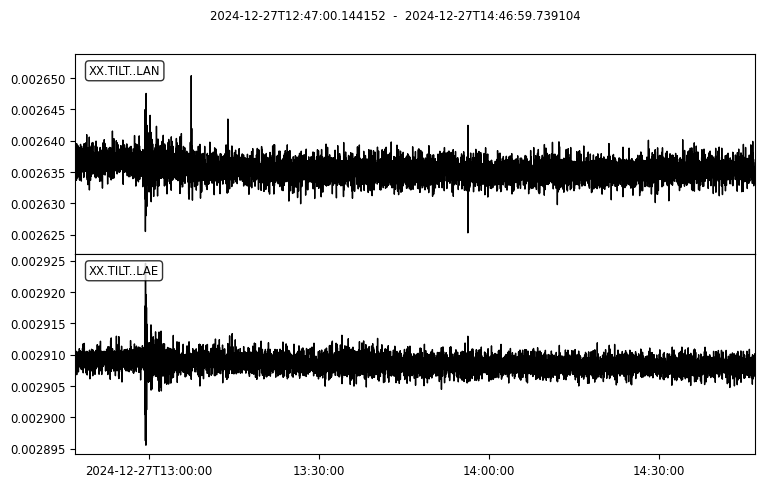

In [67]:
st_tilt.plot();

### Load RaspShake Data

In [68]:
st_rasp = __read_sds(config['path_to_data'], "AM.RACB0.00.EH*", config['tbeg'], config['tend'])

inv_rasp = obs.read_inventory(config['path_to_inv']+"station_AM_RACB0.xml")

st_rasp = st_rasp.remove_response(inv_rasp, output="ACC")


In [69]:
st_rasp

3 Trace(s) in Stream:
AM.RACB0.00.EHE | 2024-12-27T12:46:59.997000Z - 2024-12-27T14:46:59.997000Z | 100.0 Hz, 720001 samples
AM.RACB0.00.EHN | 2024-12-27T12:46:59.997000Z - 2024-12-27T14:46:59.997000Z | 100.0 Hz, 720001 samples
AM.RACB0.00.EHZ | 2024-12-27T12:46:59.997000Z - 2024-12-27T14:46:59.997000Z | 100.0 Hz, 720001 samples

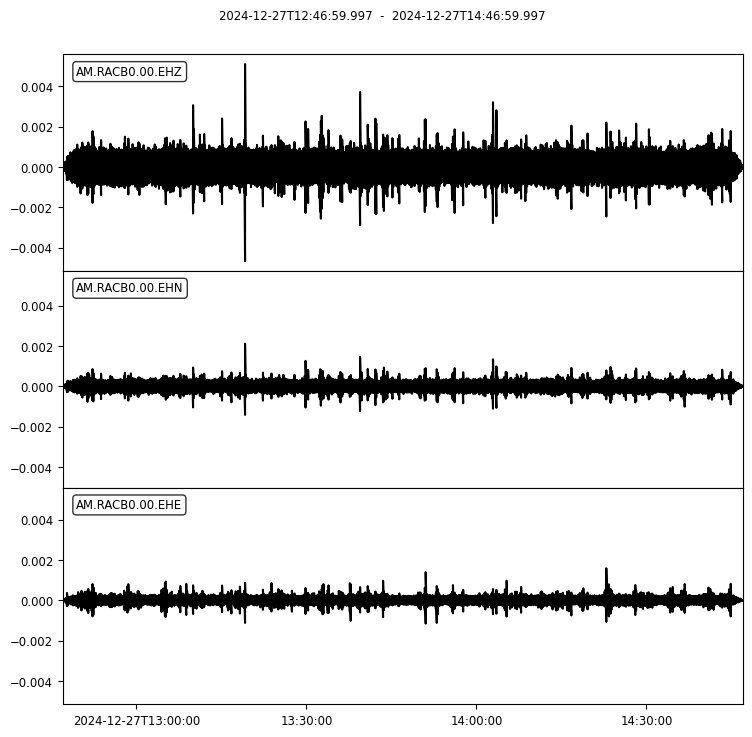

In [70]:
st_rasp.plot();

### Combine Data

In [83]:
st0 = obs.Stream()
st0 += st_seis.copy()
st0 += st_tilt.copy()
st0 += st_rasp.copy()

In [84]:
st = st0.copy()

st = st.detrend("demean")
st = st.taper(0.05)
st = st.filter("bandpass", freqmin=0.2, freqmax=0.5, corners=4, zerophase=True)

st = st.trim(config['tbeg'], config['tend'])

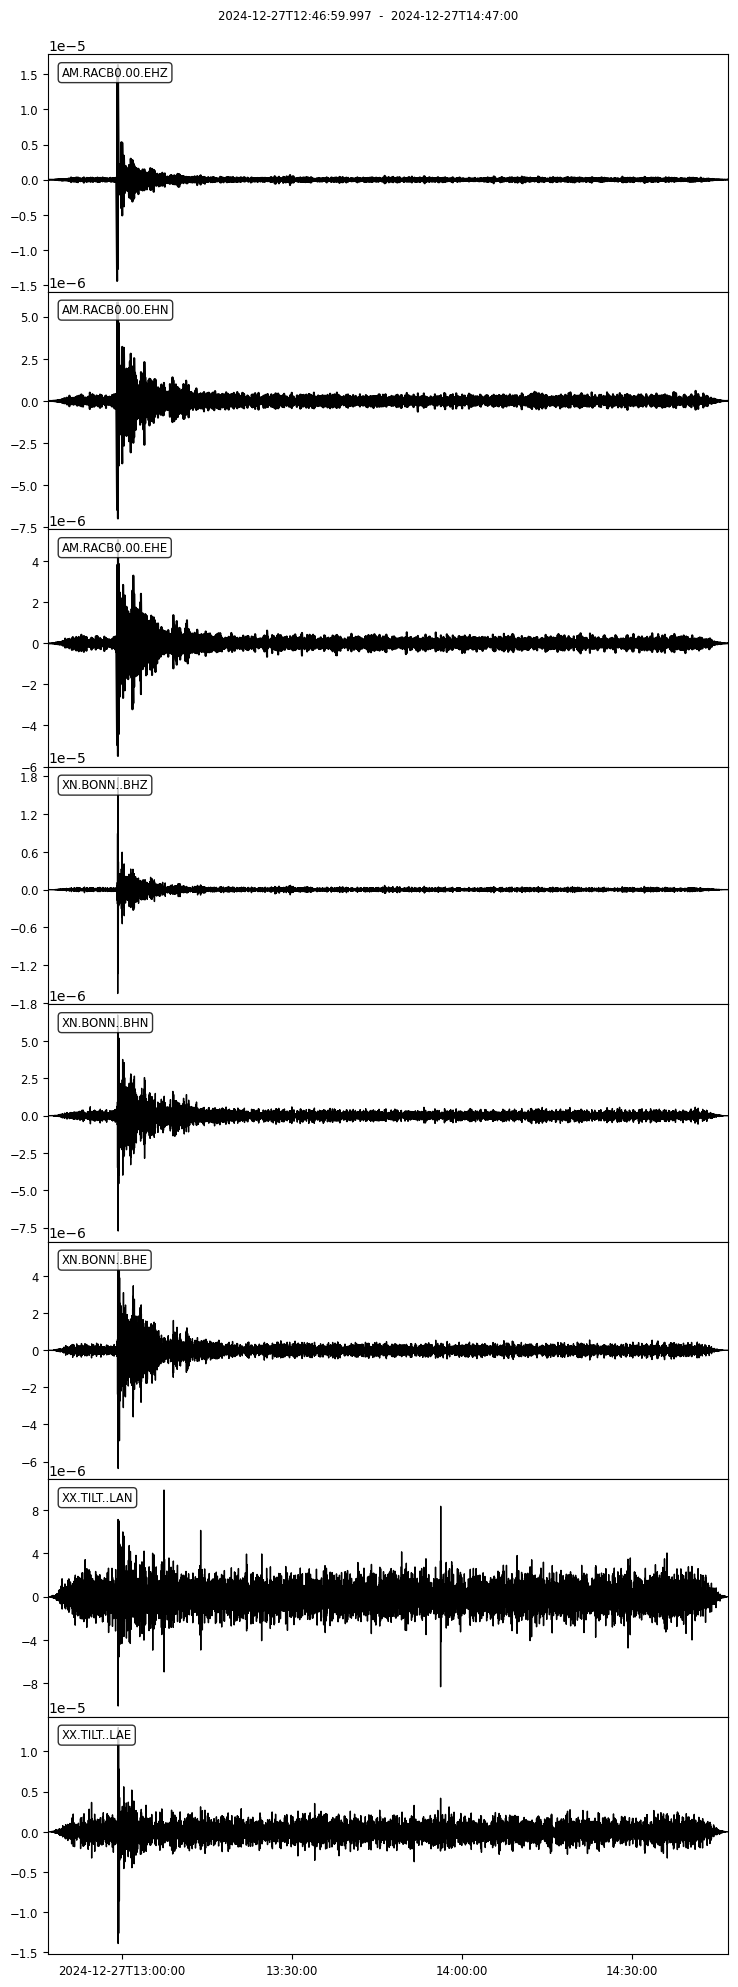

In [85]:
st.plot(equal_scale=False);

8 Trace(s) in Stream:
XN.BONN..BHE    | 2024-12-27T12:47:00.000000Z - 2024-12-27T14:46:59.000000Z | 1.0 Hz, 7200 samples
XN.BONN..BHN    | 2024-12-27T12:47:00.000000Z - 2024-12-27T14:46:59.000000Z | 1.0 Hz, 7200 samples
XN.BONN..BHZ    | 2024-12-27T12:47:00.000000Z - 2024-12-27T14:46:59.000000Z | 1.0 Hz, 7200 samples
XX.TILT..LAE    | 2024-12-27T12:47:00.144152Z - 2024-12-27T14:46:59.144152Z | 1.0 Hz, 7200 samples
XX.TILT..LAN    | 2024-12-27T12:47:00.144152Z - 2024-12-27T14:46:59.144152Z | 1.0 Hz, 7200 samples
AM.RACB0.00.EHE | 2024-12-27T12:46:59.997000Z - 2024-12-27T14:46:58.997000Z | 1.0 Hz, 7200 samples
AM.RACB0.00.EHN | 2024-12-27T12:46:59.997000Z - 2024-12-27T14:46:58.997000Z | 1.0 Hz, 7200 samples
AM.RACB0.00.EHZ | 2024-12-27T12:46:59.997000Z - 2024-12-27T14:46:58.997000Z | 1.0 Hz, 7200 samples


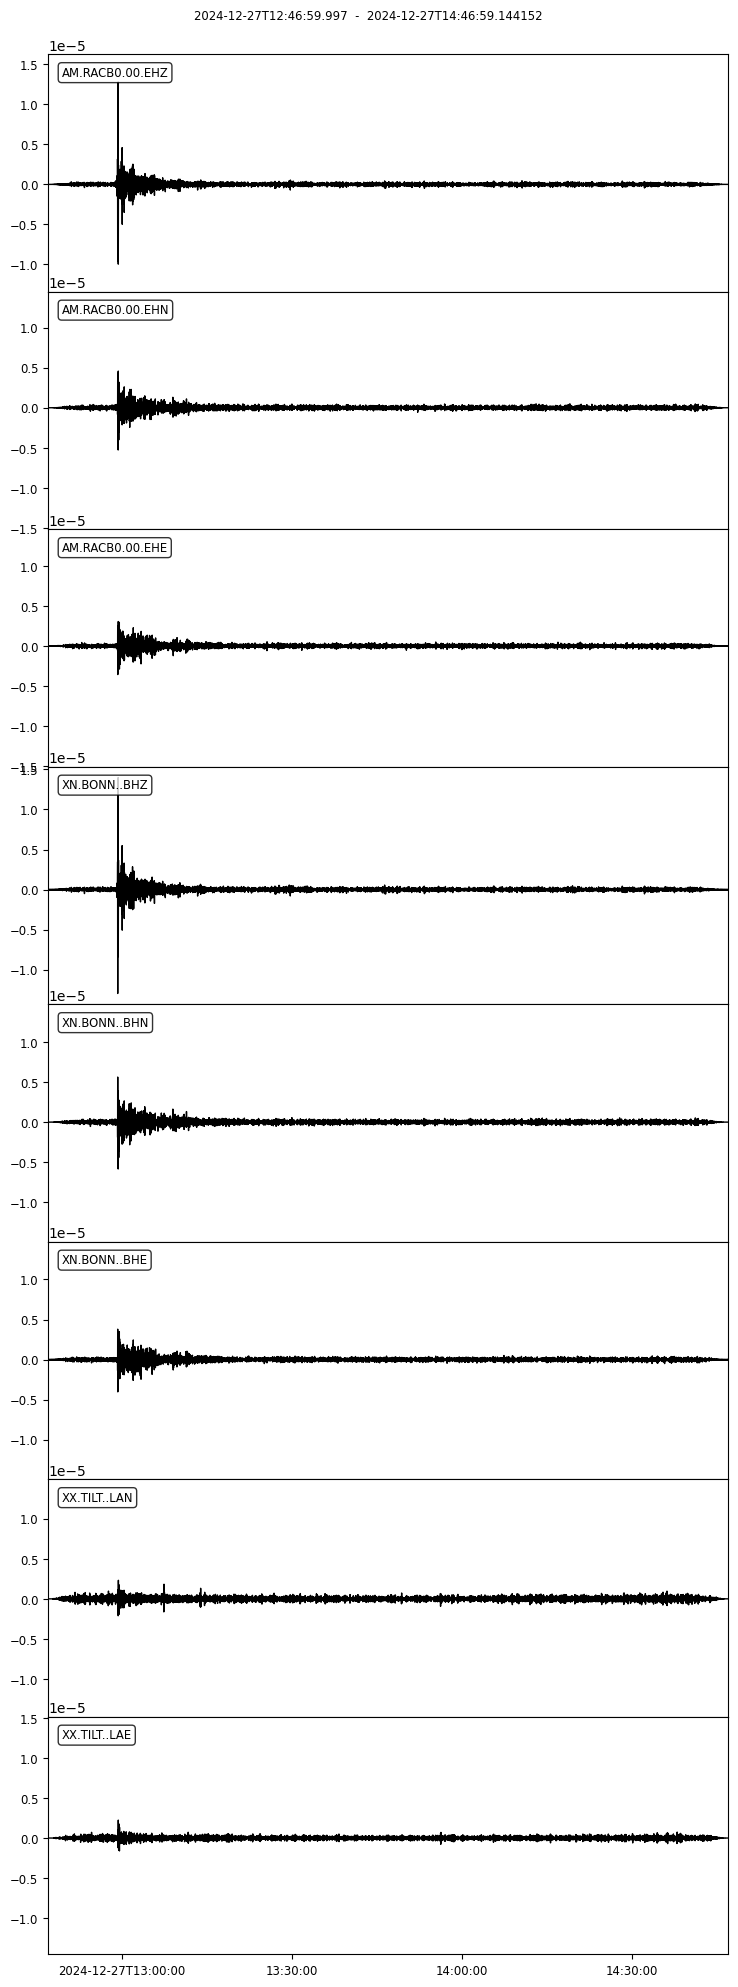

In [86]:
stx = st.copy()

# stx = stx.trim(config['tbeg']+3100, config['tend']-2200)

stx = stx.resample(1.0, no_filter=True)

stx = __trim_stream(stx, set_common=True, set_interpolate=True)

print(stx)

stx.plot();

In [78]:
from andbro__crosscorrelationTraces import __crosscorrelationTraces

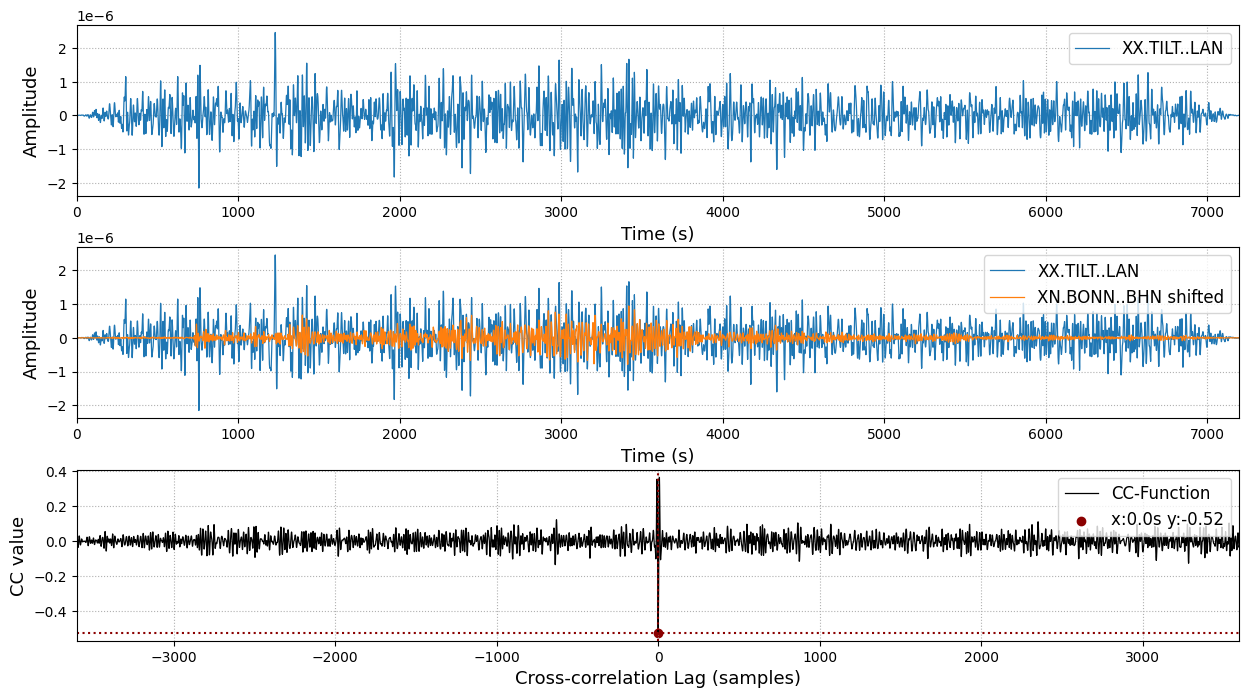

Maximum Correlation: 
 x: 0s 
 y: -0.52


In [79]:
tr1 = stx.select(channel="LAN")[0]
tr2 = stx.select(channel="BHN")[0]

out = __crosscorrelationTraces(tr1, tr2)

# out['figure'].savefig(config['path_to_figs']+"CC_n.png", format="png", dpi=150, bbox_inches='tight')


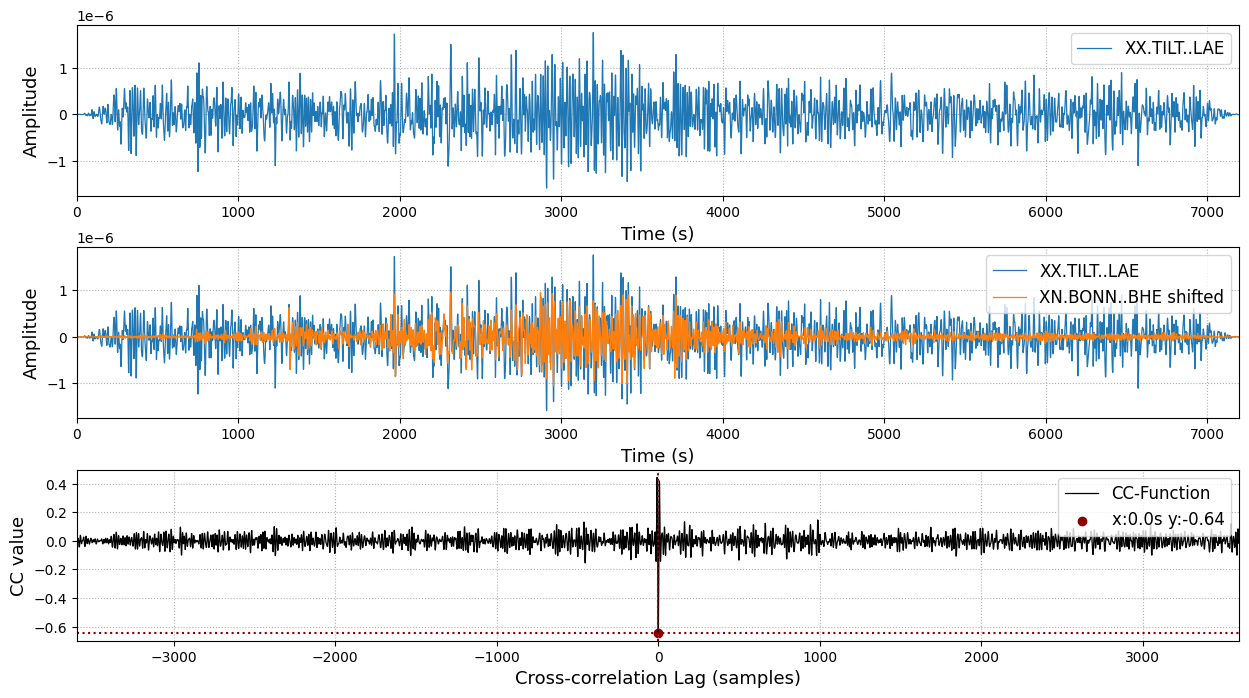

Maximum Correlation: 
 x: 0s 
 y: -0.64


In [80]:
tr1 = stx.select(channel="LAE")[0]
tr2 = stx.select(channel="BHE")[0]

out = __crosscorrelationTraces(tr1, tr2)

# out['figure'].savefig(config['path_to_figs']+"CC_e.png", format="png", dpi=150, bbox_inches='tight')


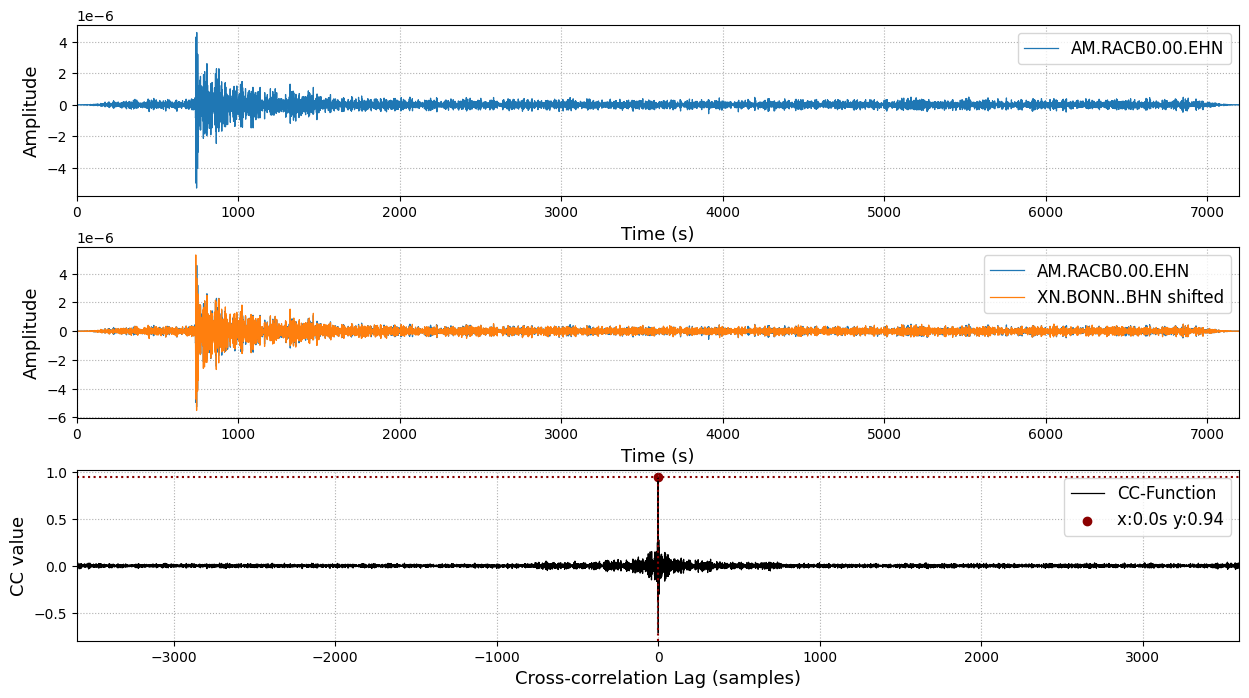

Maximum Correlation: 
 x: 0s 
 y: 0.94


In [87]:
tr1 = stx.select(channel="EHN")[0]
tr2 = stx.select(channel="BHN")[0]

out = __crosscorrelationTraces(tr1, tr2)

# out['figure'].savefig(config['path_to_figs']+"CC_e_rasp.png", format="png", dpi=150, bbox_inches='tight')


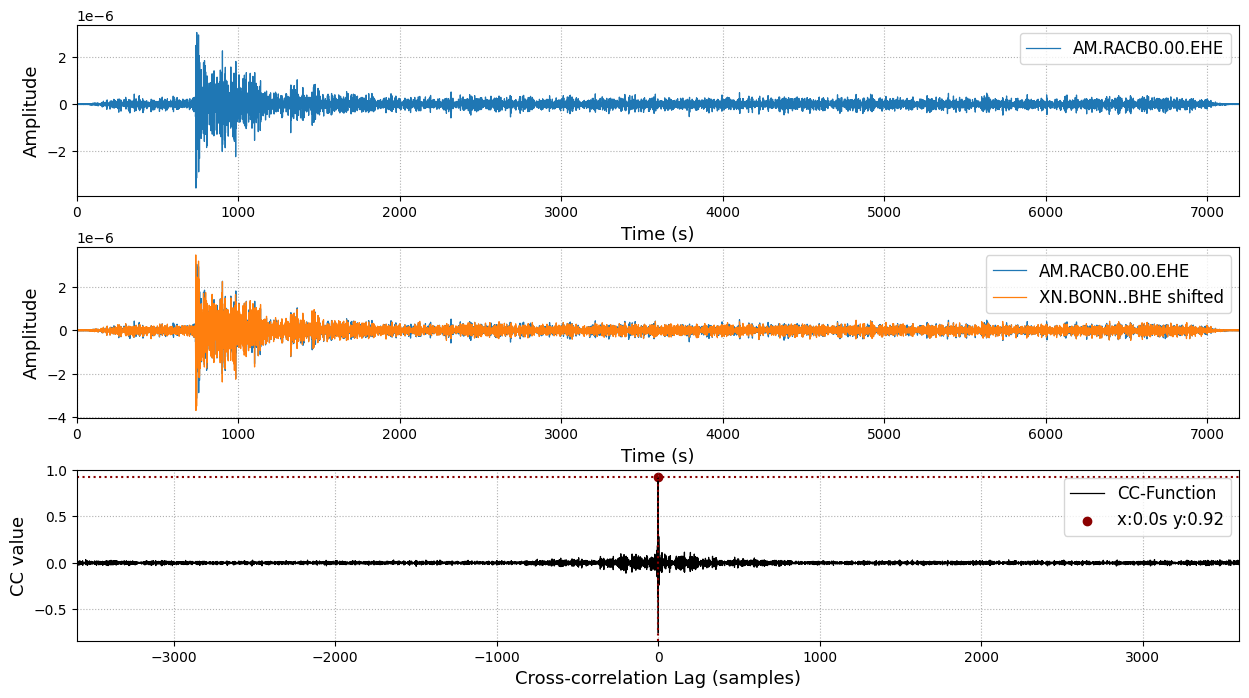

Maximum Correlation: 
 x: 0s 
 y: 0.92


In [89]:
tr1 = stx.select(channel="EHE")[0]
tr2 = stx.select(channel="BHE")[0]

out = __crosscorrelationTraces(tr1, tr2)

# out['figure'].savefig(config['path_to_figs']+"CC_N_rasp.png", format="png", dpi=150, bbox_inches='tight')


In [60]:
def __compare_psd_stream(st0, twin_sec=3600, psd="welch", time_bandwidth=None, n_win=5, plot=True):

    def __welch_psd(arr, dt, twin_sec=60):

        from scipy.signal import welch
        from scipy.signal.windows import hann

        nblock = int(1/dt * twin_sec)
        overlap = int(0.5*nblock)
        win = hann(nblock, True)

        ff, Pxx = welch(arr,
                        fs=1/dt,
                        window=win,
                        noverlap=overlap,
                        nfft=nblock,
                        scaling="density",
                        return_onesided=True)

        return ff, Pxx

    def __multitaper_psd(arr, dt, n_win=5, time_bandwidth=4.0):

        import multitaper as mt

        out_psd = mt.MTSpec(arr, nw=time_bandwidth, kspec=n_win, dt=dt, iadapt=2)

        _f, _psd = out_psd.rspec()

        f = _f.reshape(_f.size)
        psd = _psd.reshape(_psd.size)

        ## 95% confidence interval
        # _psd95 = out_psd.jackspec()
        # psd95_lower, psd95_upper = psd95[::2, 0], psd95[::2, 1]

        return f, psd

    fxxs, pxxs = {}, {}

    for tr in st0:

        seed = tr.get_id()

        if psd == "welch":
            fxxs[seed], pxxs[seed] = __welch_psd(tr.data, tr.stats.delta, twin_sec)
        elif psd == "multitaper":
            fxxs[seed], pxxs[seed] = __multitaper_psd(tr.data, tr.stats.delta, n_win=n_win, time_bandwidth=time_bandwidth)

    if plot:

        Nrow, Ncol = 1, 1

        font = 12

        fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

        for tr in st0:

            ax.plot(fxxs[tr.get_id()], pxxs[tr.get_id()], label=tr.get_id())

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.grid(ls=":", zorder=0)
        ax.legend(loc=1)

        ax.set_xlim(1/twin_sec, 0.5/tr.stats.delta)

        ax.set_xlabel("Frequency (Hz")
        ax.set_ylabel("PSD")

        plt.show();

    return fxxs, pxxs

In [61]:
st2 = st0.copy()

st2 = st2.detrend("demean")

st2 = st2.taper(0.01)

# st2 = st2.resample(1.0, no_filter=False)

fxx, pxx = __compare_psd_stream(st2, twin_sec=3600, psd="welch", plot=False)

# fxx, pxx = __compare_psd_stream(st2, n_win=10, time_bandwidth=3.5, psd="multitaper", plot=False)


ValueError: window is longer than input signal

In [160]:
models = np.load(config['workdir']+"kilauea-data/GEORG/data/"+"noise_models.npz")

In [161]:
models

NpzFile '/home/andbro/kilauea-data/GEORG/data/noise_models.npz' with keys: low_noise, model_periods, high_noise

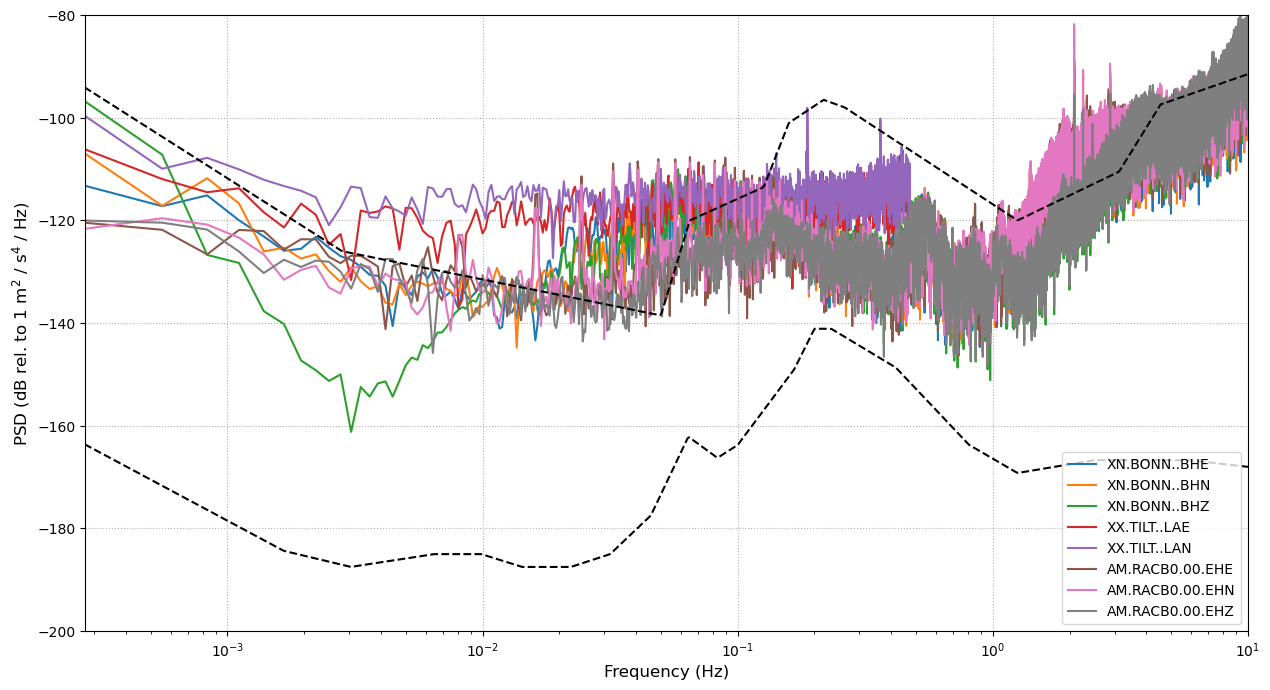

In [22]:
Nrow, Ncol = 1, 1

font = 12

fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

for tr in st2:

    ax.plot(fxx[tr.get_id()], 10*np.log10(pxx[tr.get_id()]), label=tr.get_id())

ax.plot(1/models['model_periods'], models['low_noise'], color="k", ls="--")
ax.plot(1/models['model_periods'], models['high_noise'], color="k", ls="--")

ax.set_xscale("log")
# ax.set_yscale("log")

ax.set_ylim(-200, -80)

ax.grid(ls=":", zorder=0)
ax.legend(loc=4)

fmax = 0.5/tr.stats.delta

if fmax < 10:
    ax.set_xlim(1/3600, fmax)
else:
    ax.set_xlim(1/3600, 10)

ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
ax.set_ylabel(r"PSD (dB rel. to 1 m$^2$ / s$^4$ / Hz)", fontsize=font)

plt.show();

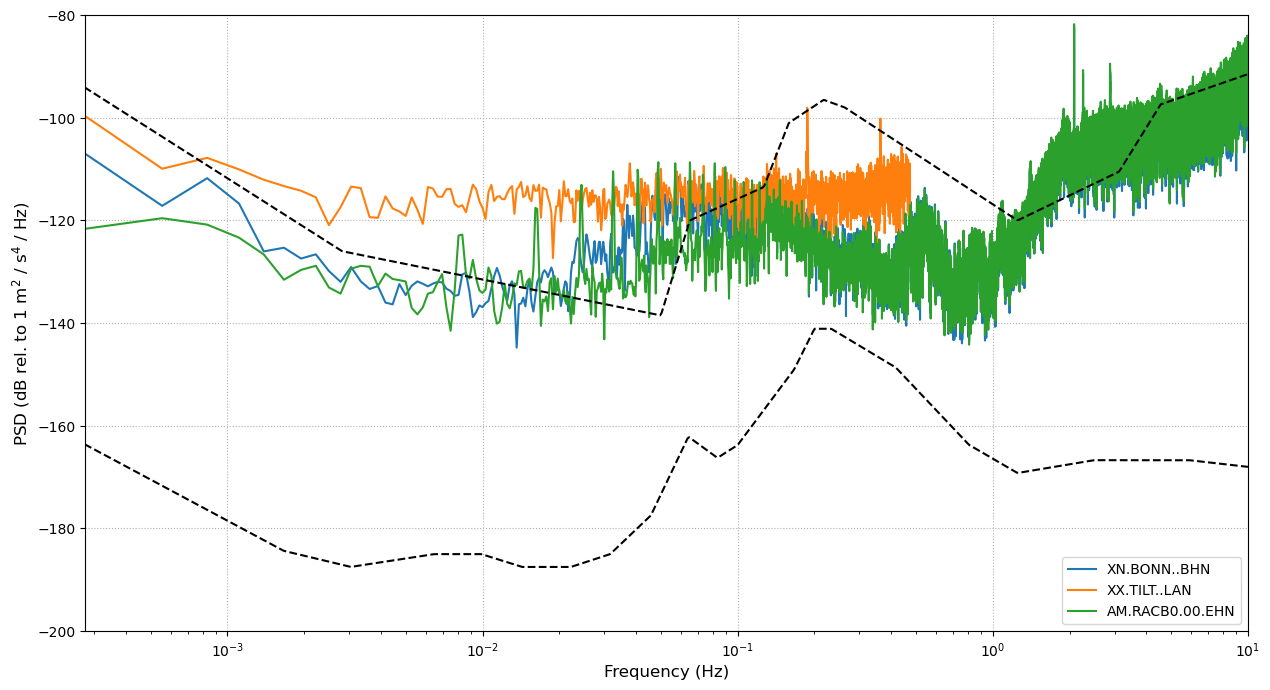

In [23]:
Nrow, Ncol = 1, 1

font = 12

fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

for tr in st2.select(channel="*N"):

    ax.plot(fxx[tr.get_id()], 10*np.log10(pxx[tr.get_id()]), label=tr.get_id())

ax.plot(1/models['model_periods'], models['low_noise'], color="k", ls="--")
ax.plot(1/models['model_periods'], models['high_noise'], color="k", ls="--")

ax.set_xscale("log")
# ax.set_yscale("log")

ax.set_ylim(-200, -80)

ax.grid(ls=":", zorder=0)
ax.legend(loc=4)

fmax = 0.5/tr.stats.delta

if fmax < 10:
    ax.set_xlim(1/3600, fmax)
else:
    ax.set_xlim(1/3600, 10)

ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
ax.set_ylabel(r"PSD (dB rel. to 1 m$^2$ / s$^4$ / Hz)", fontsize=font)

plt.show();

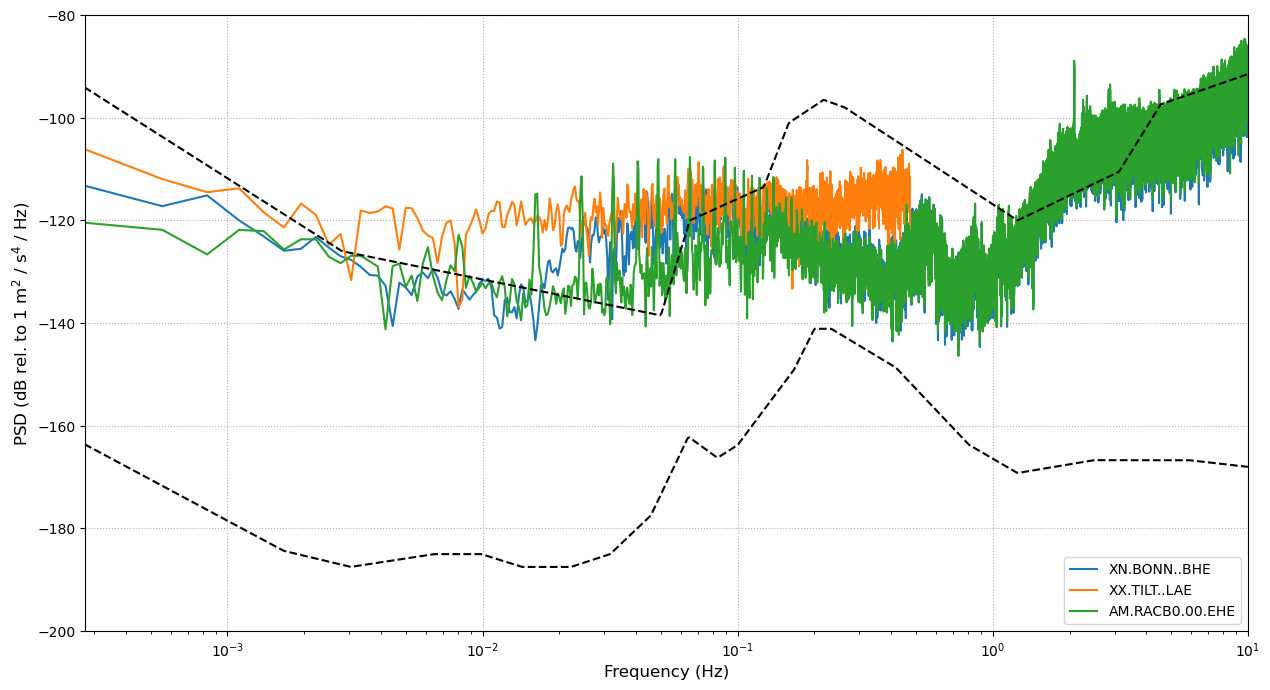

In [24]:
Nrow, Ncol = 1, 1

font = 12

fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

for tr in st2.select(channel="*E"):

    ax.plot(fxx[tr.get_id()], 10*np.log10(pxx[tr.get_id()]), label=tr.get_id())

ax.plot(1/models['model_periods'], models['low_noise'], color="k", ls="--")
ax.plot(1/models['model_periods'], models['high_noise'], color="k", ls="--")

ax.set_xscale("log")
# ax.set_yscale("log")

ax.set_ylim(-200, -80)

ax.grid(ls=":", zorder=0)
ax.legend(loc=4)

fmax = 0.5/tr.stats.delta

if fmax < 10:
    ax.set_xlim(1/3600, fmax)
else:
    ax.set_xlim(1/3600, 10)

ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
ax.set_ylabel(r"PSD (dB rel. to 1 m$^2$ / s$^4$ / Hz)", fontsize=font)

plt.show();

In [25]:
# %matplotlib tk

# shift = stx.select(channel="EHN")[0].data
# shift = np.roll(shift, -5)

# plt.plot(stx.select(channel="HHN")[0].times(), stx.select(channel="HHN")[0].data/10)
# # plt.plot(stx.select(channel="LAN")[0].times(), stx.select(channel="LAN")[0].data)
# plt.plot(stx.select(channel="EHN")[0].times(), shift)
# plt.show()

2 arrivals
	P phase arrival at 714.238 seconds
	S phase arrival at 1304.493 seconds


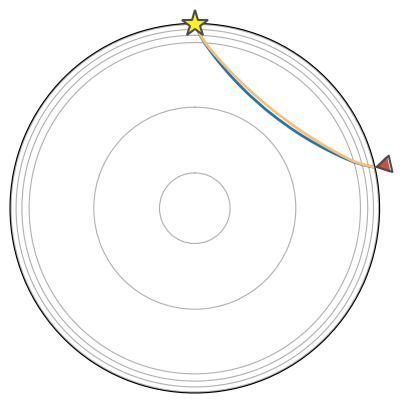

<PolarAxes: >

In [26]:
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees

lat_event = 47.29
lon_event = 151.15
time_event = "2024-12-27 12:47:36.7"
dep_event = 10
event_id = "C202412271247A"

lat_georg = 50.728310247878376
lon_georg = 7.0890113662166385

distance_in_degree = locations2degrees(lat_georg, lon_georg, lat_event, lon_event)

model = TauPyModel(model="iasp91") # ak135 | iasp91

arrivals = model.get_travel_times(source_depth_in_km=dep_event,
                                  distance_in_degree=distance_in_degree,
                                  phase_list=["P", "S"] # "ttbasic"
                                 )

print(arrivals)

paths = model.get_ray_paths(source_depth_in_km=dep_event,
                            distance_in_degree=distance_in_degree,
                            phase_list=["P", "S"] # "ttbasic"
                            )

paths.plot_rays()

In [27]:
from obspy.clients.syngine import Client

client = Client()

In [28]:
syn_model = "iasp91_2s" # "ak135f_2s" | "prem_a_2s" | "iasp91_2s"

lat_event = 47.29
lon_event = 151.15
time_event = "2024-12-27 12:47:36.7"
dep_event = 10
event_id = "C202412271247A"

lat_georg = 50.728310
lon_georg = 7.089011

synx = client.get_waveforms(model=syn_model,
                            receiverlatitude=lat_georg,
                            receiverlongitude=lat_georg,
                            networkcode="XX",
                            stationcode="GEORG",
                            locationcode=None,
                            eventid=f"GCMT:{event_id}",
                            sourcelatitude=lat_event,
                            sourcelongitude=lon_event,
                            sourcedepthinmeters=dep_event*1000,
                            origintime=time_event,
                            starttime=None,
                            endtime=None,
                            dt=1/20,
                           )

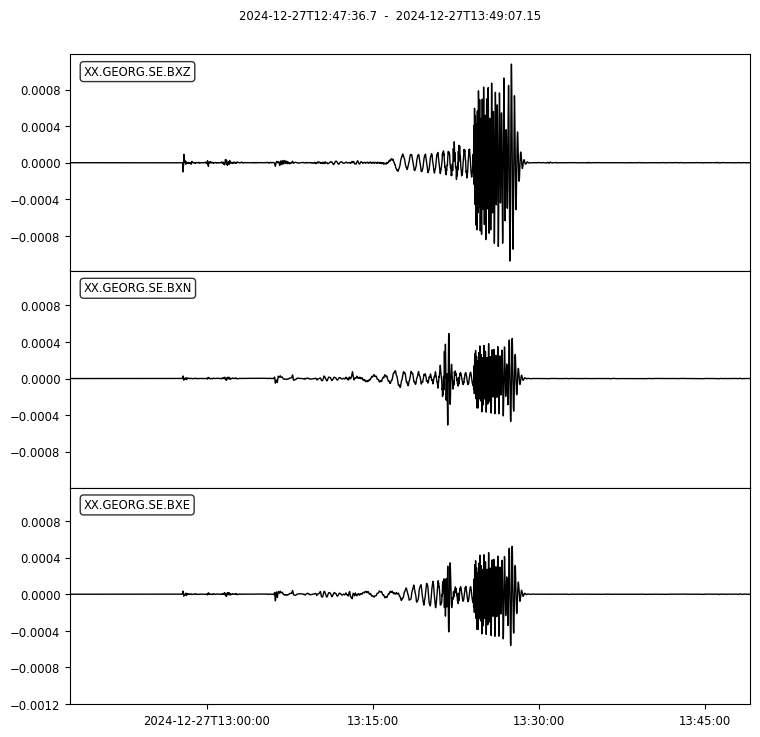

In [29]:
synx.plot();

In [9]:
import obspy as obs

In [12]:
st_ring0 = obs.read(config['workdir']+"/kilauea-data/GEORG/data/2024/XX/GEORG/BJZ.D/"+"XX.GEORG.10.BJZ.D.2024.362")

In [24]:
st_ring = st_ring0.copy()

st_ring = st_ring.detrend("demean")
st_ring = st_ring.taper(0.05)
st_ring = st_ring.filter("bandpass", freqmin=0.01, freqmax=0.1, corners=4, zerophase=True)
# # st_ring = st_ring.filter("lowpass", freq=0.1, corners=4, zerophase=True)

st_ring = st_ring.trim(config['tbeg']-3600, config['tbeg']+2*3600)

In [25]:
%matplotlib tk

In [26]:
st_ring.plot();

(-1e-08, 1e-08)

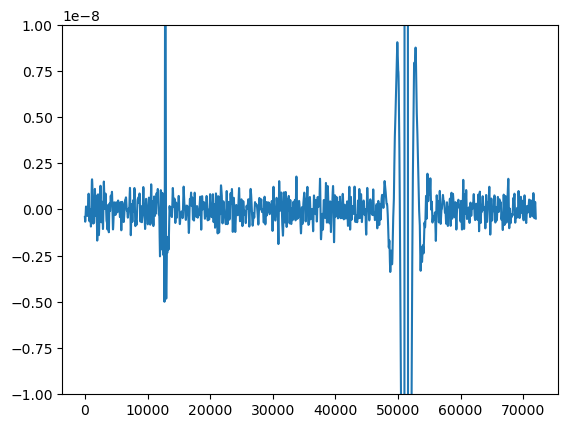

In [16]:
plt.plot(st_ring[0].data)
plt.ylim(-1e-8, 1e-8)

In [36]:
import obspy as obs

st_ring = obs.read("/home/andbro/kilauea-data/GEORG/data/2024/XX/GEORG/BJZ.D/XX.GEORG.10.BJZ.D.2024.362")

In [ ]:
st_ring.plot();

In [4]:
st_ring0 = obs.read(config['workdir']+"kilauea-data/GEORG/data/2024/XX/GEORG/BJZ.D/"+"XX.GEORG.20.BJZ.D.2024.361")

NameError: name 'config' is not defined

In [5]:
st_ring0.plot();

NameError: name 'st_ring0' is not defined

In [229]:
%matplotlib tk

plt.plot(st_ring0[0].data)

In [16]:
st_ring0 = obs.read("/import/kilauea-data/GEORG/data/2024/XX/GEORG/FJZ.D/"+"XX.GEORG..FJZ.D.2024.361")

In [17]:
%matplotlib tk

plt.plot(st_ring0[0].data[:10000])

In [35]:
72e-6*np.sin(np.deg2rad(50.72831))*3.55/632.8e-9

312.69520355434327